In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=np.array([[4.427600818242255,-0.2055493353671238,4.427600818242255],
[2.9460178356229356,-0.2613303877995026,2.9460178356229356],
[3.1040674098561647,1.3052260562340352,3.1040674098561647],
[5.609476963557052,3.6679948308177455,5.609476963557052],
[3.2180217763769474,-0.6708519396932702,3.2180217763769474],
[3.5059398674481463,-0.1483511634077948,3.5059398674481463],
[4.593492764236247,-2.108242147585418,4.593492764236247],
[2.807751857521425,0.37878498037997205,2.807751857521425],
[3.0757008280100706,-0.565585410987993,3.0757008280100706],
[2.8292839628675344,0.32991475520853697,2.8292839628675344],
[3.0283242373466632,-0.39130643811406,3.0283242373466632],
[2.967291041466846,0.34571582147832947,2.967291041466846],
[3.4431738711466258,-1.0213857868476557,3.4431738711466258],
[3.907249135408928,1.5321584185607056,3.907249135408928],
[4.027526406076244,-1.8114587491710108,4.027526406076244],
[3.628641047692023,1.2604494706540021,3.628641047692023],
[2.900076792541271,0.09735897013860546,2.900076792541271],
[3.439130912171139,1.5988291747324683,3.439130912171139],
[3.3776227414316513,-0.09090386665932276,3.3776227414316513],
[4.162893666313032,-0.7046632006598422,4.162893666313032]])
x=data[:,0]
y=data[:,1]
z=data[:,2]
X=[1,1,1,1,1]
def f(X):
  z_est=X[0]+X[1]*x+X[2]*x**2+X[3]*y+X[4]*y**2
  error=np.mean((z-z_est)**2)
  return error
f(X)

np.float64(330.1716799298878)

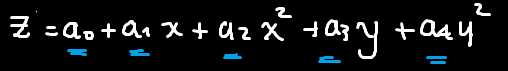

In [3]:
#Implementación del algoritmo del lobo gris
N=100 #Población de lobos
class lobo:
  def __init__(self, funcion):
    self.X=np.random.uniform(low=-10, high=10, size=5) #Valores de constantes aleatorias
    self.n=len(self.X)
    self.funcion=funcion
    self.val=self.funcion(self.X)
  def fitness(self):
    return self.funcion(self.X)
  def mover(self, a, alfa, beta, delta):
    #Respecto al alfa
    for j in range(5):
      x=[]
      for lider in [alfa, beta, delta]:
        C=2*np.random.rand()
        A=2*a*np.random.rand()-a
        D=np.abs(lider.X[j]*C-self.X[j])
        xn=lider.X[j]-A*D
        x.append(xn)
      tmp=np.sum(x)/3
      self.X[j]=np.clip(tmp, a_min=-10, a_max=10)
    self.val=self.funcion(self.X)

lobos=[lobo(f) for i in range(N)]
def getLideres(lobos):
  score=[lo.val for lo in lobos]
  index=list(range(len(lobos)))
  tmp=sorted(zip(score, index), reverse=False)[:3]
  alfa, beta, delta=lobos[tmp[0][1]], lobos[tmp[1][1]], lobos[tmp[2][1]]
  return alfa, beta, delta

alfa,beta,delta=getLideres(lobos)

In [4]:
lobos[1].mover(2,alfa, beta, delta)

In [5]:
error=[]
a=2
num=500
da=2/num
lobos=[lobo(f) for i in range(N)]
for i in range(num):
  a=a-da
  alfa, beta, delta=getLideres(lobos)
  #print(i,alfa.val, beta.val, delta.val)
  for lo in lobos:
    lo.mover(a, alfa, beta, delta)
  error.append(alfa.val)
  print('\r',i,error[-1], end='')

 499 7.338190397774317e-065

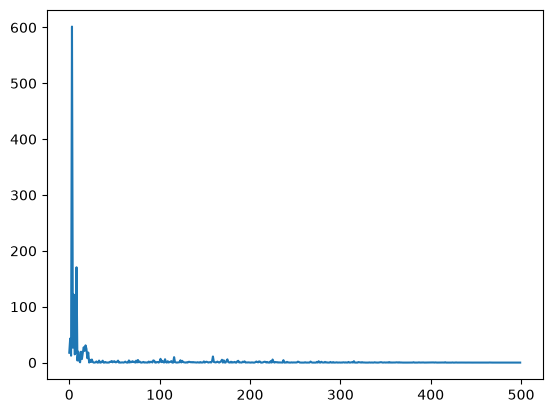

In [8]:
plt.plot(error)

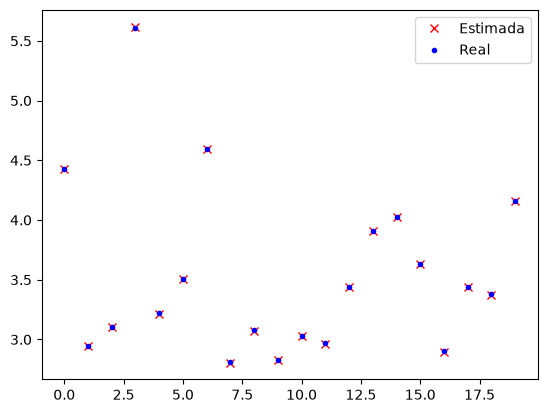

In [9]:
X=alfa.X
z_est=X[0]+X[1]*x+X[2]*x**2+X[3]*y+X[4]*y**2
plt.plot(z_est,'xr', label='Estimada')
plt.plot(z,'.b', label='Real')
plt.legend()
